In [ ]:
import torch
from torchvision import datasets, transforms, models
from torch import nn, optim

# transforms
transform = transforms.Compose([
    # transform=transforms,
    transforms.ToTensor(),
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=[.485, .456, .406], std=[.229, .224, .225])
])

train_data = datasets.ImageFolder("dataset/train", transform=transform)
val_data = datasets.ImageFolder("dataset/val", transform=transform)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=True)

# model
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, len(train_data.classes))

# training
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(3):
    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch} done")

c:\Users\ab226\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\ab226\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 0 done
Epoch 1 done
Epoch 2 done


In [2]:
val_loader = torch.utils.data.DataLoader(val_data, batch_size=32, shuffle=False)

model.eval()

correct = 0
total = 0

with torch.no_grad():  # no gradients needed
    for images, labels in val_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 69.38%


In [3]:
torch.save(train_data.classes, "classes.pth")
torch.save(model.state_dict(), "car_brand.pth")

Predicted brand: Dodge


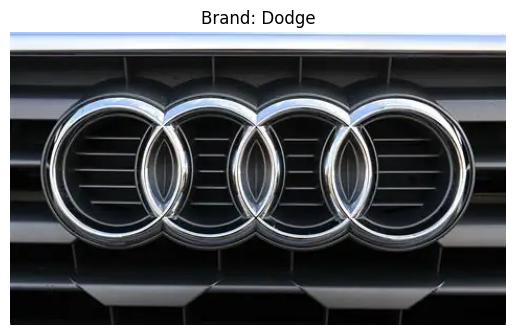

In [22]:
from PIL import Image
import matplotlib.pyplot as plt
import torch

# load image
# img_path = "./temp_images/do.jpg"
img_path = "D:/ai-doroob/temp_images/au_logo.webp"
img = Image.open(img_path).convert("RGB")

# keep a copy for display
img_display = img.copy()

# apply transform for model
img_tensor = transform(img)
img_tensor = img_tensor.unsqueeze(0)  # add batch dimension

# run inference
model.eval()
with torch.no_grad():
    outputs = model(img_tensor)
    _, predicted = torch.max(outputs, 1)

# get class name
class_names = train_data.classes
predicted_label = class_names[predicted.item()]

print("Predicted brand:", predicted_label)

# show image with prediction
plt.imshow(img_display)
plt.title(f"Brand: {predicted_label}")
plt.axis("off")
plt.show()